# Q3 — Circuit Board Homography

- **(a)** manually pick ≈6 point correspondences, estimate homography, warp one image onto the other's viewpoint  
- **(b)** subtract the warped image from the reference to visualise differences  
- **(c)** use SIFT to find and match keypoints automatically  
- **(d)** estimate homography from SIFT matches, warp and subtract, compare with (a)/(b)

c1: 570 × 683
c2: 579 × 626


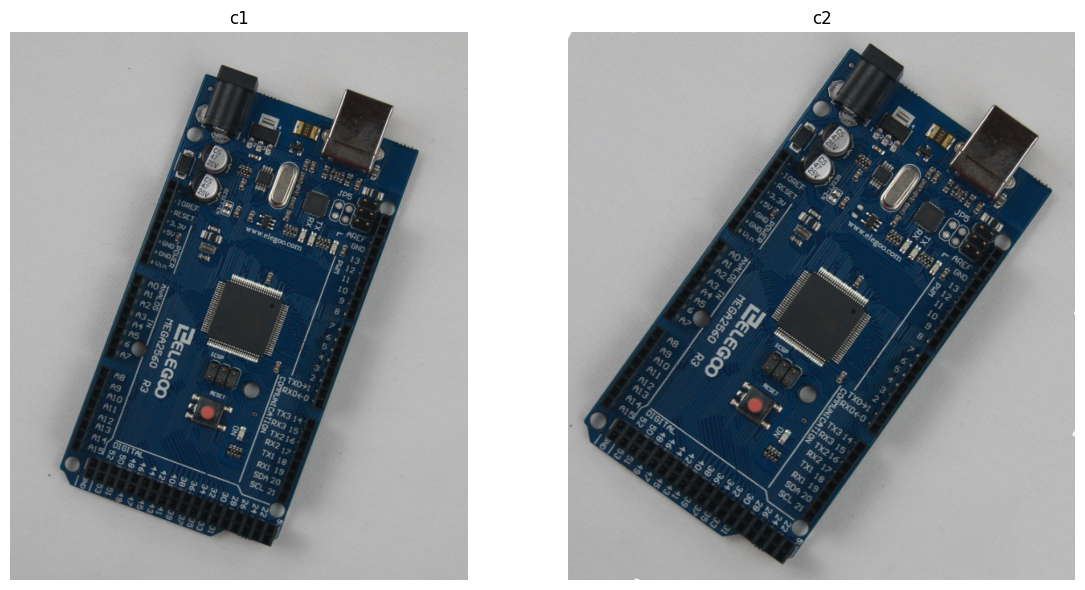

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

qdir = os.path.join('..', 'question')

# load at 1/4 resolution, same as the assignment snippet
c1 = cv2.imread(os.path.join(qdir, 'c1.jpg'), cv2.IMREAD_REDUCED_COLOR_4)
c2 = cv2.imread(os.path.join(qdir, 'c2.jpg'), cv2.IMREAD_REDUCED_COLOR_4)

c1_rgb = cv2.cvtColor(c1, cv2.COLOR_BGR2RGB)
c2_rgb = cv2.cvtColor(c2, cv2.COLOR_BGR2RGB)

print(f'c1: {c1.shape[1]} × {c1.shape[0]}')
print(f'c2: {c2.shape[1]} × {c2.shape[0]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(c1_rgb); axes[0].set_title('c1'); axes[0].axis('off')
axes[1].imshow(c2_rgb); axes[1].set_title('c2'); axes[1].axis('off')
plt.tight_layout()
plt.show()

## Part (a) — Manual point correspondences + homography


In [2]:
# 6 manually identified corresponding points (x, y) in the reduced-resolution images
# Landmarks chosen: ATmega chip corners, USB connector, mounting holes
pts1 = np.float32([
    [188, 416],
    [251, 630],
    [338, 624],
    [163, 366],
    [399, 484],
    [127, 470],
])

pts2 = np.float32([
    [173, 355],
    [178, 578],
    [263, 595],
    [162, 300],
    [359, 476],
    [100, 391],
])

H, mask_h = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
print('Homography matrix H:')
print(np.round(H, 4))
print(f'\nRANSAC inliers: {mask_h.ravel().sum()} / {len(pts1)}')

Homography matrix H:
[[  0.9699  -0.2609 100.082 ]
 [  0.2627   0.977  -99.1526]
 [ -0.       0.       1.    ]]

RANSAC inliers: 6 / 6


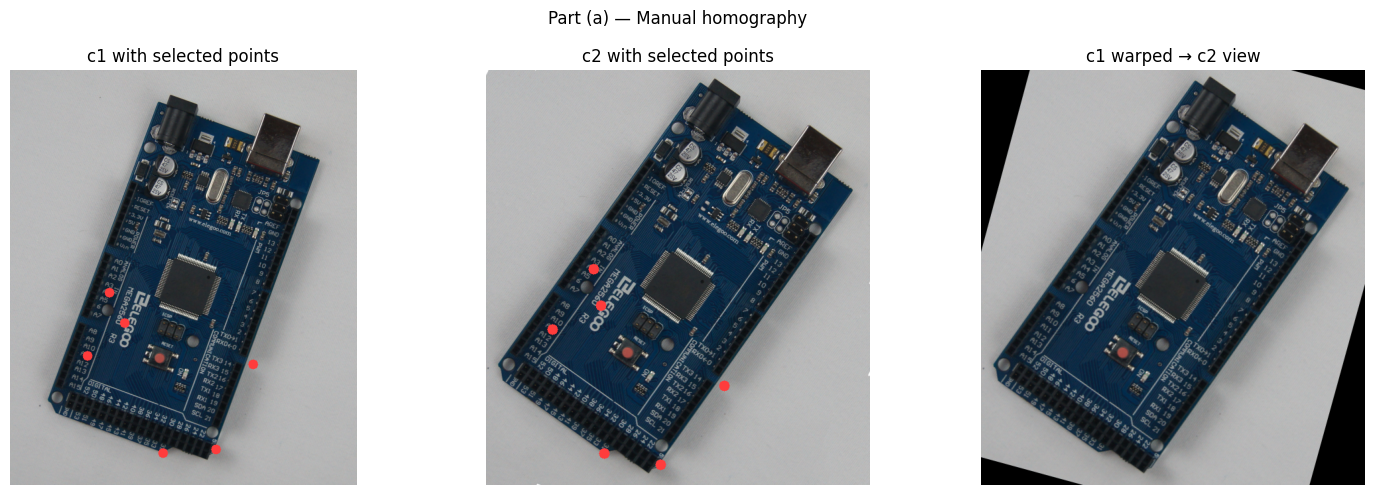

In [3]:
h2, w2 = c2.shape[:2]
warped_manual = cv2.warpPerspective(c1, H, (w2, h2))
warped_manual_rgb = cv2.cvtColor(warped_manual, cv2.COLOR_BGR2RGB)

# show the correspondence points on both images
vis1 = c1_rgb.copy()
vis2 = c2_rgb.copy()
for p1, p2 in zip(pts1, pts2):
    cv2.circle(vis1, tuple(p1.astype(int)), 8, (255, 60, 60), -1)
    cv2.circle(vis2, tuple(p2.astype(int)), 8, (255, 60, 60), -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(vis1);            axes[0].set_title('c1 with selected points'); axes[0].axis('off')
axes[1].imshow(vis2);            axes[1].set_title('c2 with selected points'); axes[1].axis('off')
axes[2].imshow(warped_manual_rgb); axes[2].set_title('c1 warped → c2 view');   axes[2].axis('off')
plt.suptitle('Part (a) — Manual homography', fontsize=12)
plt.tight_layout()
plt.savefig('q3a_warped_manual.png', dpi=150)
plt.show()

## Part (b) — Difference image


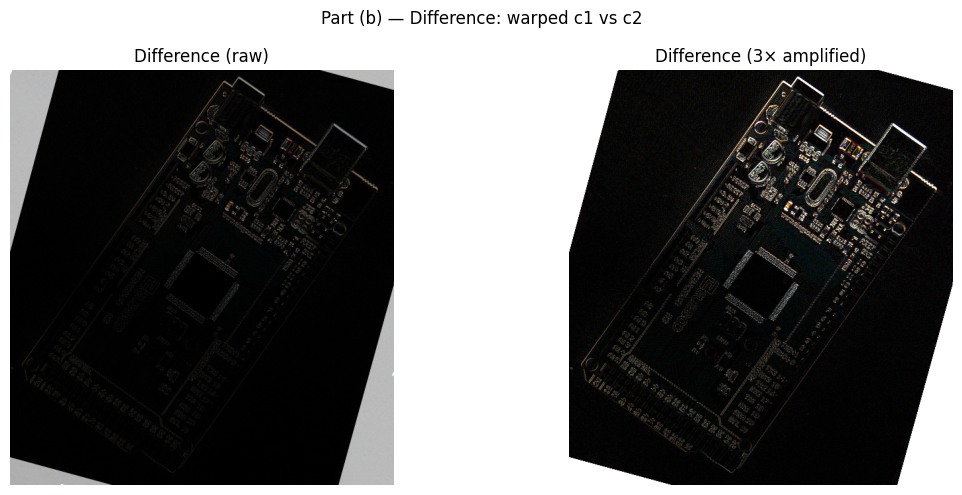

Mean absolute diff (manual H): 18.56


In [4]:
diff_manual = cv2.absdiff(warped_manual, c2)
diff_manual_rgb = cv2.cvtColor(diff_manual, cv2.COLOR_BGR2RGB)

# amplify to make small differences more visible
diff_amp = np.clip(diff_manual_rgb.astype(np.float32) * 3, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(diff_manual_rgb); axes[0].set_title('Difference (raw)')
axes[1].imshow(diff_amp);        axes[1].set_title('Difference (3× amplified)')
for ax in axes:
    ax.axis('off')
plt.suptitle('Part (b) — Difference: warped c1 vs c2', fontsize=12)
plt.tight_layout()
plt.savefig('q3b_diff_manual.png', dpi=150)
plt.show()

print(f'Mean absolute diff (manual H): {diff_manual.mean():.2f}')

## Part (c) — SIFT keypoints and matching


In [5]:
c1_gray = cv2.cvtColor(c1, cv2.COLOR_BGR2GRAY)
c2_gray = cv2.cvtColor(c2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(c1_gray, None)
kp2, des2 = sift.detectAndCompute(c2_gray, None)
print(f'Keypoints: {len(kp1)} in c1,  {len(kp2)} in c2')

bf = cv2.BFMatcher()
raw_matches = bf.knnMatch(des1, des2, k=2)

# Lowe ratio test
good_matches = [m for m, n in raw_matches if m.distance < 0.75 * n.distance]
print(f'Matches after ratio test: {len(good_matches)}')

Keypoints: 1439 in c1,  1489 in c2
Matches after ratio test: 1029


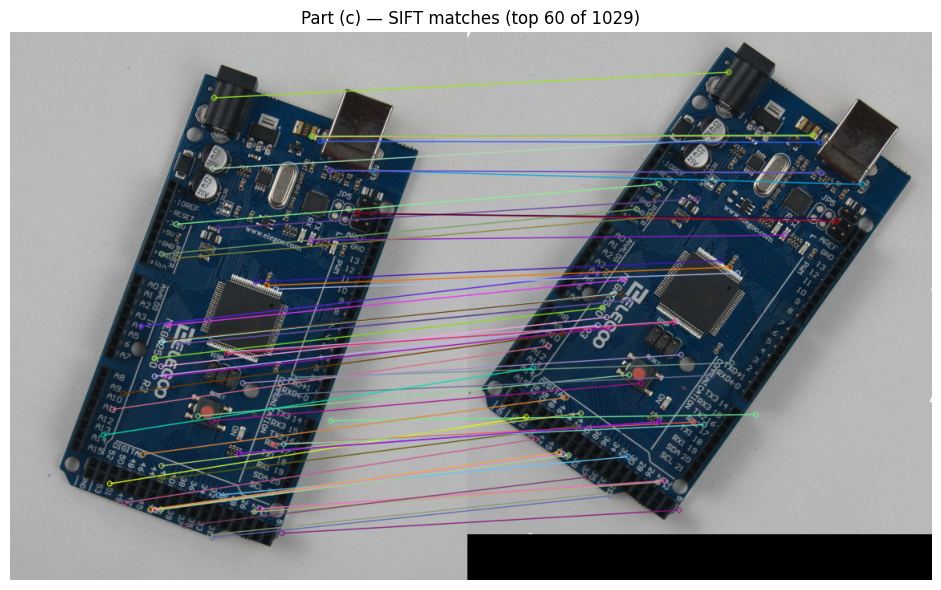

In [6]:
# draw top 60 matches
match_img = cv2.drawMatches(
    c1, kp1, c2, kp2,
    sorted(good_matches, key=lambda x: x.distance)[:60],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
match_img_rgb = cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.imshow(match_img_rgb)
plt.title(f'Part (c) — SIFT matches (top 60 of {len(good_matches)})')
plt.axis('off')
plt.tight_layout()
plt.savefig('q3c_sift_matches.png', dpi=150)
plt.show()

## Part (d) — Homography from SIFT matches, compare with (a)/(b)


In [7]:
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

H_sift, mask_sift = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
n_inliers = mask_sift.ravel().sum()
print(f'SIFT homography: {n_inliers} inliers out of {len(good_matches)} matches')
print('H (SIFT):')
print(np.round(H_sift, 4))

SIFT homography: 995 inliers out of 1029 matches
H (SIFT):
[[  0.9647  -0.2639 101.516 ]
 [  0.2639   0.9647 -96.0488]
 [  0.       0.       1.    ]]


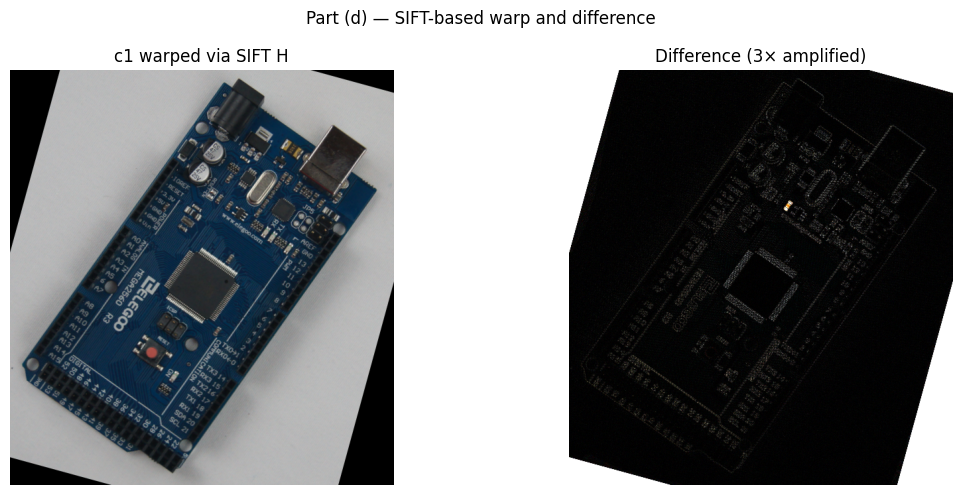

Mean absolute diff (manual H): 18.556
Mean absolute diff (SIFT H)  : 16.345


In [8]:
warped_sift = cv2.warpPerspective(c1, H_sift, (w2, h2))
diff_sift = cv2.absdiff(warped_sift, c2)

warped_sift_rgb = cv2.cvtColor(warped_sift, cv2.COLOR_BGR2RGB)
diff_sift_rgb   = cv2.cvtColor(diff_sift,   cv2.COLOR_BGR2RGB)
diff_sift_amp   = np.clip(diff_sift_rgb.astype(np.float32) * 3, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(warped_sift_rgb); axes[0].set_title('c1 warped via SIFT H')
axes[1].imshow(diff_sift_amp);   axes[1].set_title('Difference (3× amplified)')
for ax in axes:
    ax.axis('off')
plt.suptitle('Part (d) — SIFT-based warp and difference', fontsize=12)
plt.tight_layout()
plt.savefig('q3d_sift_warp_diff.png', dpi=150)
plt.show()

print(f'Mean absolute diff (manual H): {diff_manual.mean():.3f}')
print(f'Mean absolute diff (SIFT H)  : {diff_sift.mean():.3f}')

## Side-by-side comparison

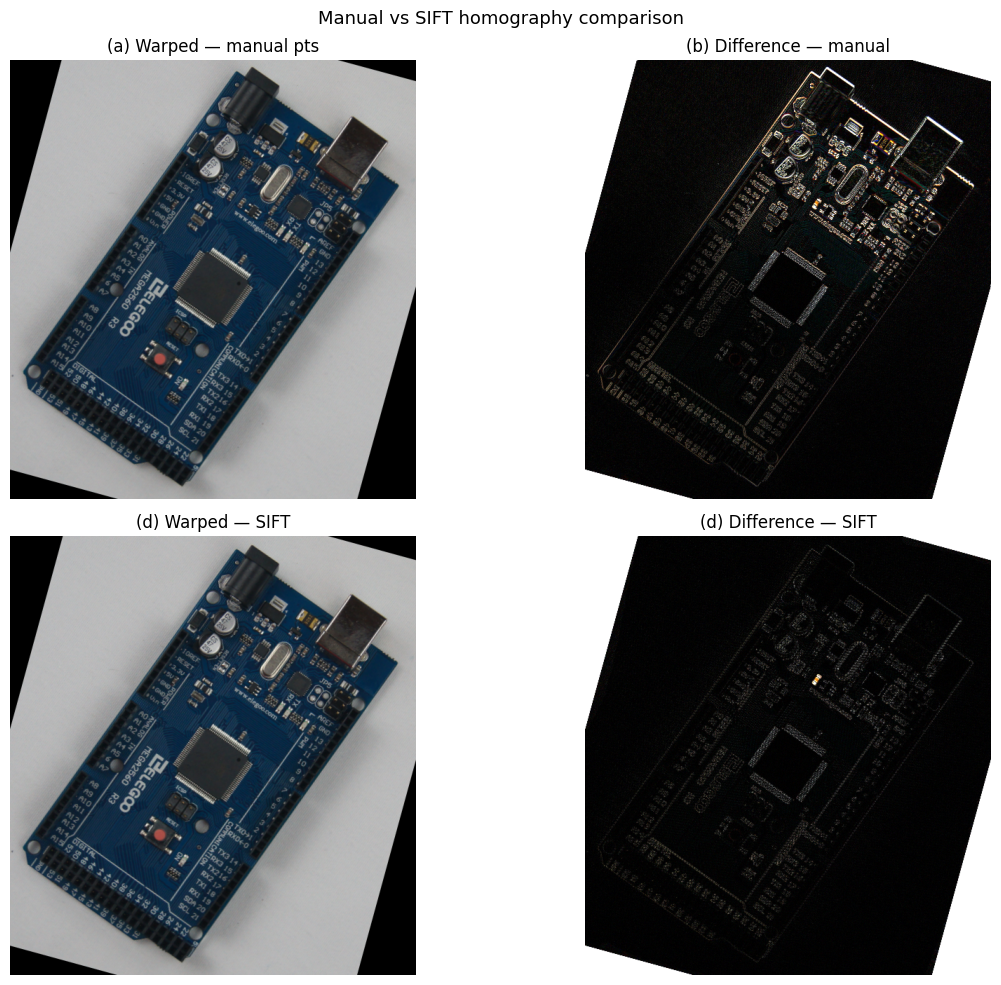

In [9]:
diff_manual_amp = np.clip(
    cv2.cvtColor(diff_manual, cv2.COLOR_BGR2RGB).astype(np.float32) * 3, 0, 255
).astype(np.uint8)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes[0, 0].imshow(warped_manual_rgb); axes[0, 0].set_title('(a) Warped — manual pts')
axes[0, 1].imshow(diff_manual_amp);   axes[0, 1].set_title('(b) Difference — manual')
axes[1, 0].imshow(warped_sift_rgb);   axes[1, 0].set_title('(d) Warped — SIFT')
axes[1, 1].imshow(diff_sift_amp);     axes[1, 1].set_title('(d) Difference — SIFT')
for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Manual vs SIFT homography comparison', fontsize=13)
plt.tight_layout()
plt.savefig('q3_comparison.png', dpi=150)
plt.show()